In [29]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from scipy.ndimage import uniform_filter1d  # for smoothing

In [30]:
# Load and preprocess data
data = pd.read_csv('AirtrafficA4.csv')
data['PASSENGERS CARRIED'] = data['PASSENGERS CARRIED'].str.replace(',', '').astype(float)
invalid_month_rows = data[~data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]
data = data[data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]

# Create 'DATE' column
data['DATE'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['MONTH'], format='%Y-%b')
data = data.sort_values('DATE').set_index('DATE')

# Prepare the data in Prophet-compatible format
df = data[['PASSENGERS CARRIED']].reset_index().rename(columns={'DATE': 'ds', 'PASSENGERS CARRIED': 'y'})

# Optionally remove data from COVID period (March 2020 to Dec 2021)
data_filtered = data[(data.index < '2020-03-01') | (data.index > '2021-12-31')]

# Apply smoothing to reduce noise, e.g., uniform filter
data_filtered['PASSENGERS CARRIED'] = uniform_filter1d(data_filtered['PASSENGERS CARRIED'], size=3)

# Prepare data for Prophet
df = data_filtered[['PASSENGERS CARRIED']].reset_index().rename(columns={'DATE': 'ds', 'PASSENGERS CARRIED': 'y'})

# Split data into training and validation sets
train_data = df[df['ds'] < '2023-01-01']  # Train on data before 2023
validation_data = df[df['ds'] >= '2023-01-01']  # Validation on data in 2023


C:\Users\aksgu\AppData\Local\Temp\ipykernel_27644\879549531.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['PASSENGERS CARRIED'] = uniform_filter1d(data_filtered['PASSENGERS CARRIED'], size=3)


In [31]:
# Initialize and fit the Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)  # Monthly seasonality
model.fit(train_data)

# Create a future dataframe for the validation period
future = model.make_future_dataframe(periods=len(validation_data), freq='M')

# Generate forecast
forecast = model.predict(future)

23:18:29 - cmdstanpy - INFO - Chain [1] start processing
23:18:29 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\aksgu\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


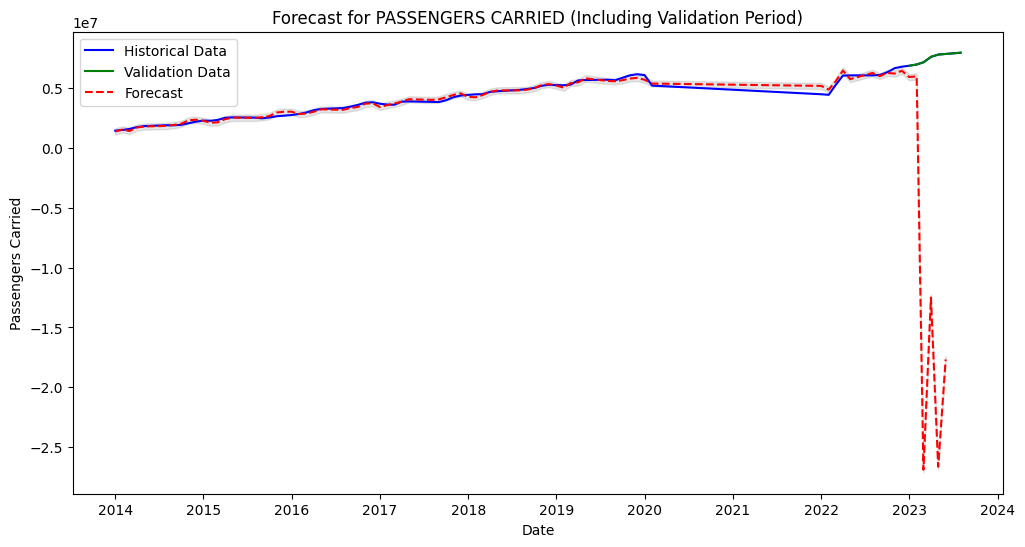

In [32]:
# Plot forecast vs. actuals
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'], label='Historical Data', color='blue')
plt.plot(validation_data['ds'], validation_data['y'], label='Validation Data', color='green')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='gray', alpha=0.2)
plt.title("Forecast for PASSENGERS CARRIED (Including Validation Period)")
plt.xlabel("Date")
plt.ylabel("Passengers Carried")
plt.legend()
plt.show()

In [33]:
# Calculate evaluation metrics
y_true = validation_data['y'].values
y_pred = forecast['yhat'][-len(validation_data):].values

mae = np.mean(np.abs(y_true - y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"Validation MAE: {mae:.2f}")
print(f"Validation MAPE: {mape:.2f}%")

# Save forecast for submission
forecast_df = forecast[['ds', 'yhat']].tail(12).copy()
forecast_df.columns = ['YEAR_MONTH', 'PASSENGERS CARRIED']
forecast_df['YEAR_MONTH'] = forecast_df['YEAR_MONTH'].dt.strftime('%Y %b').str.upper()
forecast_df.to_csv('prophet_submission.csv', index=False)

Validation MAE: 19356223.72
Validation MAPE: 255.34%


In [44]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load your dataset
df = pd.read_csv("AirtrafficA4.csv")

# Remove commas in numerical columns and convert them to float
for col in df.columns[3:]:  # Skip AIRLINE, YEAR, MONTH columns
    df[col] = df[col].replace({',': ''}, regex=True).astype(float)
    
invalid_month_rows = data[~data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]
data = data[data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]

# Create a date column for time series
data['DATE'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['MONTH'], format='%Y-%b')
data = data.sort_values('DATE')

# Now set DATE as the index and drop the DATE column after setting it as the index
data = data.set_index('DATE', drop=True)

# Handle missing values
# Replace NaNs and 0s in relevant columns with imputed values (use mean for numerical columns)
df.replace(0, np.nan, inplace=True)
imputer = SimpleImputer(strategy='mean')
df.iloc[:, 3:] = imputer.fit_transform(df.iloc[:, 3:])

# Filter out COVID-19 period (March 2020 - December 2021)
df = df[(df.index < '2020-03-01') | (df.index > '2021-12-31')]

# Drop non-numeric or categorical columns if not required by Prophet
df = df.drop(columns=['AIRLINE', 'YEAR', 'MONTH'])

# Reindex to include the entire date range with COVID period missing
date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
df = df.reindex(date_range)

# Interpolate to fill the missing COVID-19 period
df = df.interpolate(method='linear')

ValueError: 'DATE' is both an index level and a column label, which is ambiguous.

In [ ]:
# Rename the target column to 'y' and the index to 'ds' as required by Prophet
data = df[['PASSENGERS CARRIED']].rename(columns={'PASSENGERS CARRIED': 'y'}).reset_index().rename(columns={'DATE': 'ds'})

# Add exogenous variables as additional regressors
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

# Add other columns as extra regressors
for col in df.columns:
    if col != 'PASSENGERS CARRIED':
        prophet_model.add_regressor(col)

# Split data into training and validation sets (e.g., last 12 months for validation)
train_data = data[:-12]
validation_data = data[-12:]

# Fit the model
prophet_model.fit(train_data)

# Prepare future DataFrame and add exogenous variables for forecast
future = prophet_model.make_future_dataframe(periods=12, freq='MS')
for col in df.columns:
    if col != 'PASSENGERS CARRIED':
        future[col] = df[col].values

# Generate forecast
forecast = prophet_model.predict(future)


In [ ]:
# Calculate MAPE on the validation set
validation_forecast = forecast[-12:]
mape = mean_absolute_percentage_error(validation_data['y'], validation_forecast['yhat'])
print(f"MAPE on validation set: {mape * 100:.2f}%")

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train_data['ds'], train_data['y'], label="Training Data", color="blue")
plt.plot(validation_data['ds'], validation_data['y'], label="Validation Data", color="green")
plt.plot(forecast['ds'], forecast['yhat'], label="Forecast", color="red", linestyle='--')
plt.xlabel("Date")
plt.ylabel("Passengers Carried")
plt.title("Forecast for PASSENGERS CARRIED (Including Validation Period)")
plt.legend()
plt.show()

# Save forecasted results
forecast_result = forecast[['ds', 'yhat']].rename(columns={'ds': 'YEAR_MONTH', 'yhat': 'PASSENGERS CARRIED'})
forecast_result['YEAR_MONTH'] = forecast_result['YEAR_MONTH'].dt.strftime('%Y %b').str.upper()
forecast_result.to_csv("prophet_forecast_passengers.csv", index=False)
